# Task 3

> - Train a Random Forest and compare its accuracy and feature importance to the single Decision Tree.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

iris = load_iris()

X_train, X_test, y_train, y_test = train_test_split(
    iris.data,
    iris.target,
    test_size=0.2,
    random_state=42,
    stratify=iris.target
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9


Compare Decision Tree vs Random Forest

In [12]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

tree_accuracy = accuracy_score(
    y_test,
    model.predict(X_test)
)

print("Decision Tree:", tree_accuracy)
print("Random Forest:", rf_accuracy)

Decision Tree: 0.9333333333333333
Random Forest: 0.9


Feature Importance

In [13]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": rf.feature_importances_
})

print(importance.sort_values(
    by="Importance",
    ascending=False
))

             Feature  Importance
3   petal width (cm)    0.437185
2  petal length (cm)    0.431466
0  sepal length (cm)    0.116349
1   sepal width (cm)    0.015000


Visualize:

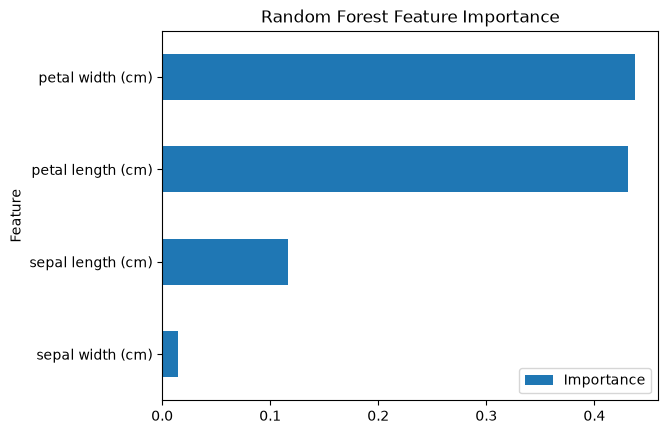

In [15]:
import matplotlib.pyplot as plt

importance.sort_values(
    by="Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

plt.title("Random Forest Feature Importance")
plt.show()